In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch_directml
import matplotlib.pyplot as plt
import os

# Setup Device AMD
device = torch_directml.device()
print(f"Dispositivo attivo: {device}")

Dispositivo attivo: privateuseone:0


In [3]:
# Trasformazioni
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Percorsi (adattati alla tua cartella)
train_dir = './chest_xray/train'
val_dir = './chest_xray/test' 

train_data = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_data = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Immagini di training: {len(train_data)}")
print(f"Classi rilevate: {train_data.classes}")

Immagini di training: 5216
Classi rilevate: ['NORMAL', 'PNEUMONIA']


In [4]:
# Carico il modello pre-addestrato
model = models.mobilenet_v2(weights='DEFAULT')

# Congelo i parametri per il Transfer Learning
for param in model.parameters():
    param.requires_grad = False

# Modifico il classificatore finale
model.classifier[1] = nn.Linear(model.last_channel, 2) 

model = model.to(device)
print("Modello configurato e inviato alla GPU AMD.")

Modello configurato e inviato alla GPU AMD.


In [10]:
import torch

# 1. Configurazione dei Pesi (peso 6.0 ai sani e 1.0 ai malati)
class_weights = torch.tensor([6.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 2. Abbasso il Learning Rate a 0.0005 per evitare balzi troppo bruschi
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Reset delle liste per i grafici
train_losses = []
train_accuracies = []

epochs = 7 # 7 epoche sono perfette per questo secondo test
print("Inizio Addestramento (Giro 2 - Modello Bilanciato)...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calcolo accuratezza
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoca {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Acc Train: {epoch_acc:.2f}%")

print("Training completato!")

Inizio Addestramento (Giro 2 - Modello Bilanciato)...
Epoca 1/7 - Loss: 0.1967 - Acc Train: 89.63%
Epoca 2/7 - Loss: 0.1784 - Acc Train: 90.95%
Epoca 3/7 - Loss: 0.1706 - Acc Train: 91.39%
Epoca 4/7 - Loss: 0.1603 - Acc Train: 91.62%
Epoca 5/7 - Loss: 0.1515 - Acc Train: 92.43%
Epoca 6/7 - Loss: 0.1523 - Acc Train: 92.22%
Epoca 7/7 - Loss: 0.1476 - Acc Train: 92.93%
Training completato!


In [11]:
model.eval() # Imposto il modello in modalità valutazione (disattiva Dropout)
test_correct = 0
test_total = 0

with torch.no_grad(): # Disattiva il calcolo dei gradienti per risparmiare memoria GPU
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"Accuratezza finale sul Test Set: {100. * test_correct / test_total:.2f}%")

Accuratezza finale sul Test Set: 86.06%


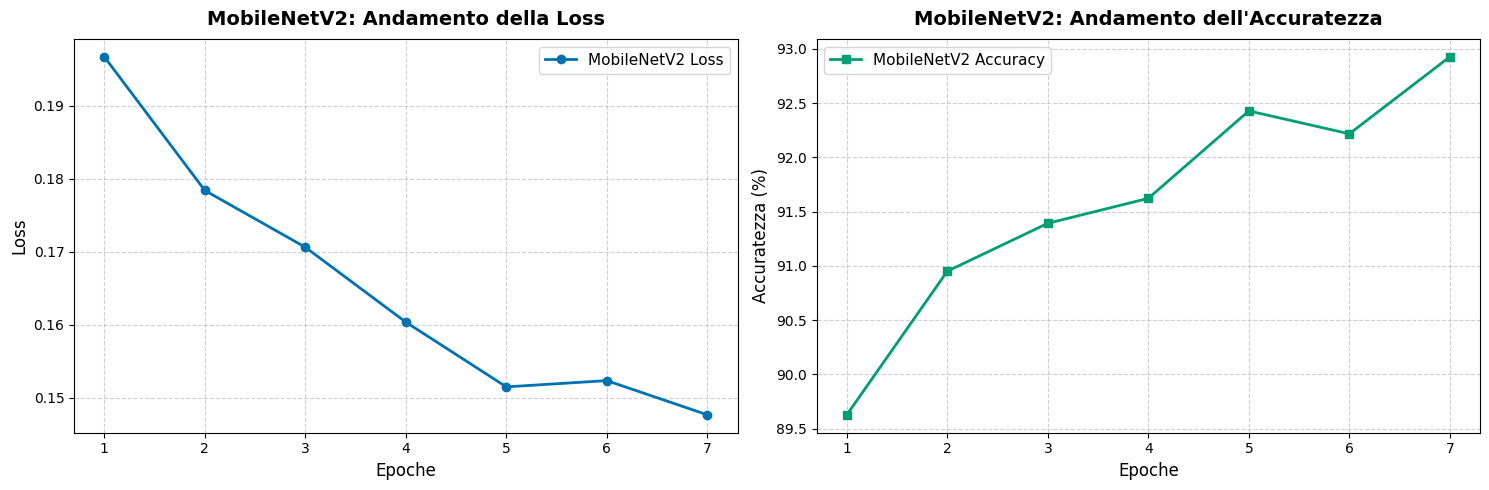

In [14]:
import matplotlib.pyplot as plt

# Creazione della figura con due grafici affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(train_losses) + 1)

# --- GRAFICO 1: FUNZIONE DI LOSS ---
ax1.plot(epochs_range, train_losses, marker='o', color='#0072B2', linewidth=2, label='MobileNetV2 Loss')
ax1.set_title('MobileNetV2: Andamento della Loss', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(epochs_range)
ax1.legend(fontsize=11)

# --- GRAFICO 2: ACCURACY ---
ax2.plot(epochs_range, train_accuracies, marker='s', color='#009E73', linewidth=2, label='MobileNetV2 Accuracy')
ax2.set_title('MobileNetV2: Andamento dell\'Accuratezza', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuratezza (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(epochs_range)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

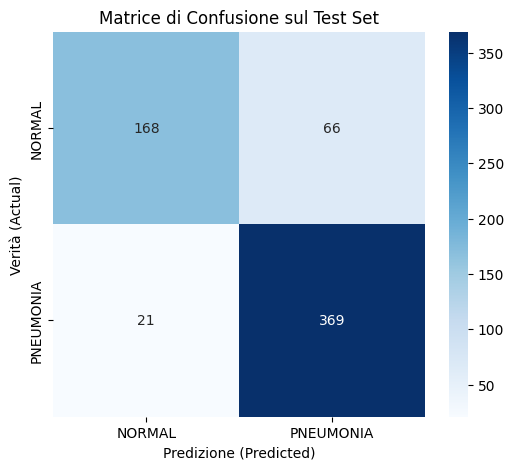

              precision    recall  f1-score   support

      NORMAL       0.89      0.72      0.79       234
   PNEUMONIA       0.85      0.95      0.89       390

    accuracy                           0.86       624
   macro avg       0.87      0.83      0.84       624
weighted avg       0.86      0.86      0.86       624



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Genero la matrice
cm = confusion_matrix(all_labels, all_preds)

# Disegno la matrice 
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_data.classes, 
            yticklabels=train_data.classes)
plt.ylabel('Verità (Actual)')
plt.xlabel('Predizione (Predicted)')
plt.title('Matrice di Confusione sul Test Set')
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_data.classes))

Architettura LENET 5

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        
        # C1: Primo strato convoluzionale (3 canali di input, 6 filtri, kernel 5x5)
        # Input: 3 x 150 x 150 ---> Output: 6 x 146 x 146
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0)
        
        # S2: Strato di Subsampling / Average Pooling (kernel 2x2, stride 2)
        # Output: 6 x 73 x 73
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # C3: Secondo strato convoluzionale (6 canali in ingresso, 16 filtri, kernel 5x5)
        # Output: 16 x 69 x 69
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        
        # S4: Secondo strato di Subsampling (kernel 2x2, stride 2)
        # Output: 16 x 34 x 34 (PyTorch approssima per difetto 69//2 = 34)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # F6 ed Output: Strati Fully Connected (Classificatore)
        # Il vettore appiattito (flattening) sarà lungo: 16 * 34 * 34 = 18.496 elementi
        self.fc1 = nn.Linear(16 * 34 * 34, 120)  # C5: Strato denso da 120 neuroni
        self.fc2 = nn.Linear(120, 84)            # F6: Strato denso da 84 neuroni
        self.fc3 = nn.Linear(84, 2)              # Output: 2 neuroni (NORMAL vs PNEUMONIA)
        
        # Attivazione LeNet-5 
        self.activation = nn.Tanh()

    def forward(self, x):
        # Blocco 1
        x = self.pool1(self.activation(self.conv1(x)))
        # Blocco 2
        x = self.pool2(self.activation(self.conv2(x)))
        
        # Appiattimento del tensore per gli strati lineari
        x = x.view(-1, 16 * 34 * 34)
        
        # Strati Fully Connected
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

In [17]:
# 1. Spostamento del modello sulla GPU/CPU disponibile
model_lenet = LeNet5().to(device)

# 2. Configurazione della Loss 
criterion_lenet = nn.CrossEntropyLoss(weight=torch.tensor([6.0, 1.0]).to(device))

# 3. Ottimizzatore Adam 
optimizer_lenet = optim.Adam(model_lenet.parameters(), lr=0.0001, weight_decay=1e-4)

In [18]:
import matplotlib.pyplot as plt

# Liste per memorizzare le metriche della LeNet-5
lenet_losses = []
lenet_accuracies = []

NUM_EPOCHS = 10

print("Inizio Training Modello 2 (LeNet-5 Adattata)...")
for epoch in range(NUM_EPOCHS):
    model_lenet.train()  # Imposta il modello in modalità addestramento
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Sposta i dati sul dispositivo corretto (GPU o CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Reset dei gradienti
        optimizer_lenet.zero_grad()
        
        # Forward pass
        outputs = model_lenet(inputs)
        loss = criterion_lenet(outputs, labels)
        
        # Backward pass e ottimizzazione
        loss.backward()
        optimizer_lenet.step()
        
        # Calcolo delle metriche temporanee
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    # Calcolo delle metriche medie dell'epoca
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    # Salvataggio nei vettori storici per i grafici
    lenet_losses.append(epoch_loss)
    lenet_accuracies.append(epoch_acc)
        
    print(f"LeNet-5 - Epoca {epoch+1}/{NUM_EPOCHS} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

print("Addestramento LeNet-5 completato con successo!")

Inizio Training Modello 2 (LeNet-5 Adattata)...
LeNet-5 - Epoca 1/10 - Loss: 0.2446 - Accuracy: 84.07%
LeNet-5 - Epoca 2/10 - Loss: 0.1702 - Accuracy: 90.70%
LeNet-5 - Epoca 3/10 - Loss: 0.1352 - Accuracy: 92.37%
LeNet-5 - Epoca 4/10 - Loss: 0.1240 - Accuracy: 93.35%
LeNet-5 - Epoca 5/10 - Loss: 0.1180 - Accuracy: 93.35%
LeNet-5 - Epoca 6/10 - Loss: 0.1031 - Accuracy: 94.42%
LeNet-5 - Epoca 7/10 - Loss: 0.0899 - Accuracy: 95.38%
LeNet-5 - Epoca 8/10 - Loss: 0.0874 - Accuracy: 95.71%
LeNet-5 - Epoca 9/10 - Loss: 0.0732 - Accuracy: 96.01%
LeNet-5 - Epoca 10/10 - Loss: 0.0741 - Accuracy: 96.30%
Addestramento LeNet-5 completato con successo!


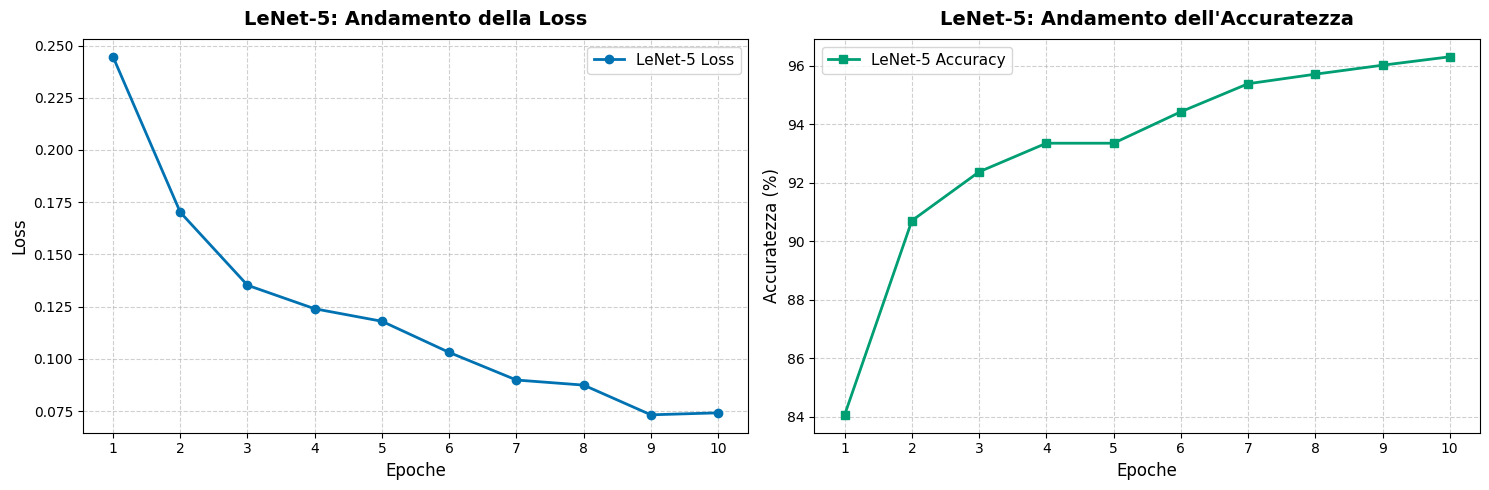

In [20]:
# Creazione della figura con due grafici affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(lenet_losses) + 1)

# --- GRAFICO 1: FUNZIONE DI LOSS ---
ax1.plot(epochs_range, lenet_losses, marker='o', color='#0072B2', linewidth=2, label='LeNet-5 Loss')
ax1.set_title('LeNet-5: Andamento della Loss', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(epochs_range)
ax1.legend(fontsize=11)

# --- GRAFICO 2: ACCURACY ---
ax2.plot(epochs_range, lenet_accuracies, marker='s', color='#009E73', linewidth=2, label='LeNet-5 Accuracy')
ax2.set_title('LeNet-5: Andamento dell\'Accuratezza', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuratezza (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(epochs_range)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
import numpy as np

# Liste per salvare tutte le predizioni e le etichette reali
all_preds = []
all_labels = []

model_lenet.eval()  #Disattiva comportamenti specifici del training (se presenti)

correct = 0
total = 0

# Disattivo il calcolo dei gradienti per velocizzare e risparmiare memoria
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model_lenet(inputs)
        _, predicted = outputs.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Salva i dati convertendoli in CPU/Numpy per la matrice di confusione
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100. * correct / total
print(f"Accuratezza finale della LeNet-5 sul Test Set: {test_accuracy:.2f}%")

Accuratezza finale della LeNet-5 sul Test Set: 79.65%


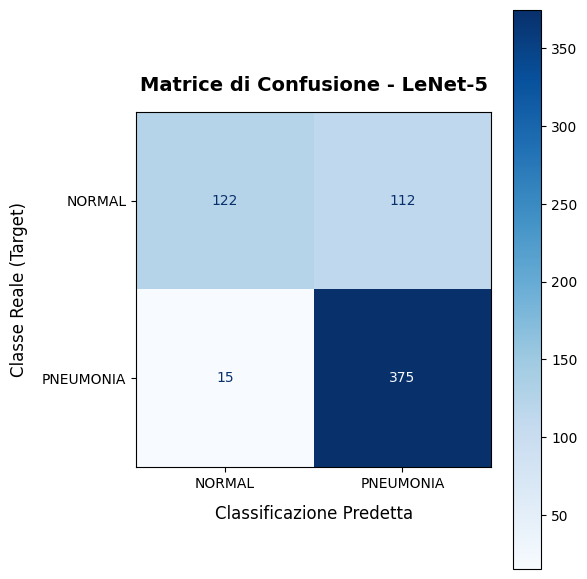

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcolo matematico della matrice di confusione
cm = confusion_matrix(all_labels, all_preds)

# Definizione dei nomi delle classi (0: Normal, 1: Pneumonia)
class_names = ['NORMAL', 'PNEUMONIA']

# Creazione del grafico della matrice
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(
    ax=ax, 
    cmap=plt.cm.Blues, 
    values_format='d'
)

ax.set_title('Matrice di Confusione - LeNet-5', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Classificazione Predetta', fontsize=12, labelpad=10)
ax.set_ylabel('Classe Reale (Target)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()